In [2]:
from functools import partial
import time

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

from adaptive_swim.ansatz import BoundaryCompliantAnsatz
from swimpde.boundary import Periodic
from swimpde.domain import Domain
from swimpde.equation import EulerBernoulli
from swimpde.solver import TimeDependentSolver

from utils import filter_results

Parameters of the equation

In [2]:
def intial_condition(x: npt.ArrayLike) -> npt.ArrayLike:
    return np.sin(x)

def initial_velocity(x: npt.ArrayLike) -> npt.ArrayLike:
    return np.zeros((x.shape[0], 1))

def forcing(x: npt.ArrayLike, t: float) -> npt.ArrayLike:
    return (1.0 - 16 * np.pi**2) * np.sin(x) * np.cos(4 * np.pi * t)

def solution(x: npt.ArrayLike, t: float) -> npt.ArrayLike:
    return np.sin(x) * np.cos(4 * np.pi * t)

boundary_condition = Periodic()

x_span = 0, np.pi
t_span = 0, 1

Create data for evaluation

Text(0, 0.5, 't')

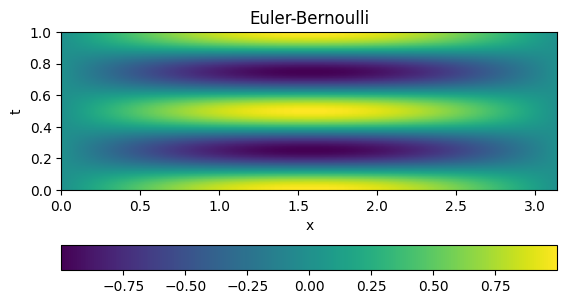

In [3]:
n_x_eval = 256
n_t_eval = 100


x_eval = np.linspace(*x_span, n_x_eval)[:, None]
t_eval = np.linspace(*t_span, n_t_eval)
u_exact = solution(x_eval, t_eval)

# Visualize the solution.
fig, ax = plt.subplots(1)
im = ax.imshow(u_exact.T, extent=[*x_span, *t_span], origin="lower")
fig.colorbar(im, ax=ax, orientation="horizontal");
ax.set_title("Euler-Bernoulli")
ax.set_xlabel("x")
ax.set_ylabel("t")

Create data for evaluation

Text(0, 0.5, 't')

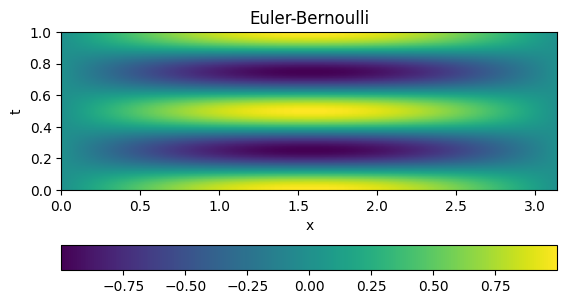

In [4]:
n_x_eval = 256
n_t_eval = 100


x_eval = np.linspace(*x_span, n_x_eval)[:, None]
t_eval = np.linspace(*t_span, n_t_eval)
u_exact = solution(x_eval, t_eval)

# Visualize the solution.
fig, ax = plt.subplots(1)
im = ax.imshow(u_exact.T, extent=[*x_span, *t_span], origin="lower")
fig.colorbar(im, ax=ax, orientation="horizontal");
ax.set_title("Euler-Bernoulli")
ax.set_xlabel("x")
ax.set_ylabel("t")

Create a domain

In [5]:
def get_domain(n_domain_points = 400):
    x_space = np.linspace(*x_span, n_domain_points)[:, None]
    
    x_interior = x_space[1:-1]
    x_boundary = x_space[[0, -1]]
    return Domain(interior_points=x_interior,
                    boundary_points=x_boundary)

Solve the equation

In [3]:
# Parameters of the solver 
activations = ["tanh", "a_tanh", "rational"]
n_inner_basis = [50, 100, 150, 200, 250, 300, 350, 400]
s_list = [0.5]
k_list = [5, 10, 20, 40]
seeds = [1, 2, 3]
regularization_scale = 1e-12
rtol = 1e-10 # relative tolerance for ODE solver
atol = 1e-10

In [7]:
# A target for the basis functions.
# Input: x (n_points, 1)
# Output: (n_points, n_basis)
# A target for the basis functions.
def periodic_target_fn(x, n_basis):
    scales = np.arange(1, n_basis + 1)
    sin_transforms = np.sin(x * scales)
    return sin_transforms

# Define the equation.
equation = EulerBernoulli(u0=intial_condition, ut0=initial_velocity)

In [ ]:
experiments = []
domain = get_domain()

for n_inner in n_inner_basis:
    n_outer = n_inner // 10
    for activation in activations:
        if activation == "tanh":
            s_sublist = [0]  # dummy variable
            k_sublist = [0]  # dummy variable
        elif activation == "a_tanh":
            s_sublist = [0]   # dummy variable
            k_sublist = k_list
        else:
            s_sublist = s_list
            k_sublist = k_list
        for s in s_sublist:
            for k in k_sublist:
                for seed in seeds:
                    # Define the ansatz.
                    ansatz = BoundaryCompliantAnsatz(
                        n_basis=n_outer,
                        n_inner_basis=n_inner,
                        activation=activation,
                        random_seed=seed,
                        target_fn=partial(periodic_target_fn, n_basis=n_outer),
                        boundary_condition=boundary_condition,
                        regularization_scale=regularization_scale,
                        initial_condition=intial_condition,
                        k=k,
                        s=s,
                    )
                    
                    # Define the solver.
                    solver = TimeDependentSolver(
                        domain=domain,
                        ansatz=ansatz,
                        forcing=forcing,
                        equation=equation,
                        regularization_scale=regularization_scale,
                        rtol=rtol,
                        atol=atol,
                    )
                    
                    # Fit the solver.
                    start = time.time()
                    solver.fit(t_span=t_span)
                    train_time = time.time() - start
            
                    u_pred = solver.evaluate(x_eval, t_eval)
                    rmse = np.linalg.norm(u_pred - u_exact) / u_pred.shape[0]
                    rel_l2 = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
                
                    experiments.append({
                        "activation": activation,
                        "n_inner": n_inner,
                        "(s_1, s_2)": (-s, s),
                        "k": k,
                        "rmse": rmse,
                        "rel_l2": rel_l2,
                        "time": train_time,
                        "seed": seed,
                    })

                    print(experiments[-1])

In [9]:
# Save results
import pandas as pd
df = pd.DataFrame(experiments)
df.to_csv("results/euler_bernoulli_results.csv", index=False)

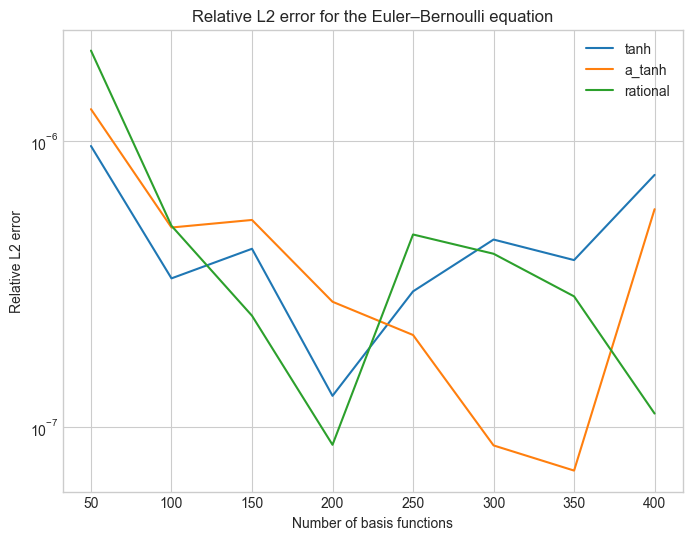

In [ ]:
import pandas as pd
df = pd.read_csv("results/euler_bernoulli_results.csv")
df = df.groupby(["activation", "n_inner", "(s_1, s_2)", "k"]).agg(rmse=("rmse", "mean"),
                                                                  rmse_std=("rmse", "std"),
                                                                  rel_l2=("rel_l2", "mean"),
                                                                  rel_l2_std=("rel_l2", "std"),
                                                                  time=("time", "mean"),
                                                                  time_std=("time", "std")).reset_index()
df.to_csv("results/euler_bernoulli_accuracy.csv")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
n_inner_np = np.asarray(n_inner_basis)
for activation in activations:
    rmse, rel_l2 = filter_results(df, activation, n_inner_basis)
    plt.plot(n_inner_np, rel_l2, label=activation)

plt.title("Relative L2 error for the Euler–Bernoulli equation")
plt.xlabel("Number of basis functions")
plt.ylabel("Relative L2 error")
plt.yscale("log")
plt.legend()
plt.show()

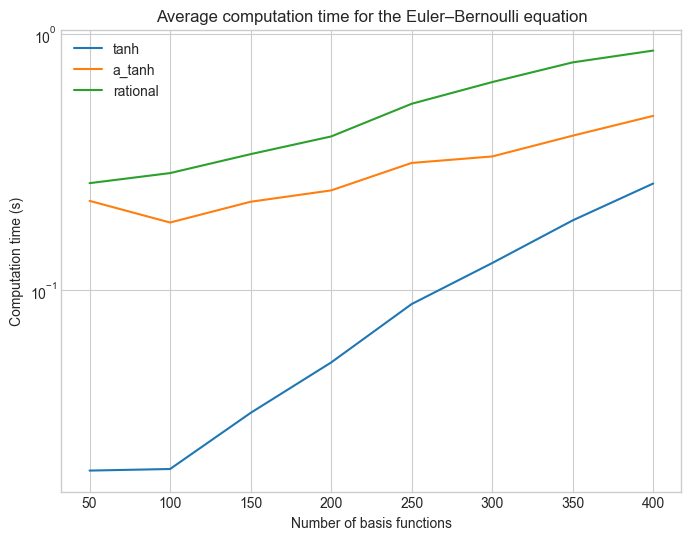

In [ ]:
import pandas as pd
df = pd.read_csv("results/euler_bernoulli_results.csv")
df = df.groupby(["activation", "n_inner"]).agg(time=("time", "mean"),
                                               time_std=("time", "std")).reset_index()
df.to_csv("results/euler_bernoulli_time")
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

n_inner_np = np.asarray(n_inner_basis)

for activation in activations:
    time_list = []
    filtered = df[df["activation"] == activation]
    for n in n_inner_basis:
        subset = filtered[filtered["n_inner"] == n]
        time_ = subset["time"]
        time_list.append(time_)
    y_time = np.array(time_list)
    plt.plot(n_inner_np, y_time, label=activation)

plt.title("Average computation time for the Euler–Bernoulli equation")
plt.xlabel("Number of basis functions")
plt.ylabel("Computation time (s)")
plt.yscale("log")
plt.legend()
plt.show()